# Atomic Nucleus Model Prototype

This notebook turns the atomic nucleus concepts into code.

## What this notebook demonstrates

- Proton number, neutron number, and mass number.
- Nuclear radius.
- Binding energy using the semi-empirical mass formula.
- Rough stability and decay tendencies.
- A toy nuclear pair potential.
- How the model maps to C++.

In [2]:
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

## 1. Basic nuclear bookkeeping

A nucleus is described by:

$$
A = Z + N
$$

where:

- $Z$ is proton number.
- $N$ is neutron number.
- $A$ is mass number.

A simple simulation should store these values directly.

In [3]:
@dataclass
class Nucleus:
    Z: int  # protons
    N: int  # neutrons

    @property
    def A(self) -> int:
        return self.Z + self.N

    @property
    def neutron_to_proton_ratio(self) -> float:
        if self.Z == 0:
            return float("inf")
        return self.N / self.Z


examples = {
    "helium-4": Nucleus(Z=2, N=2),
    "carbon-12": Nucleus(Z=6, N=6),
    "iron-56": Nucleus(Z=26, N=30),
    "uranium-238": Nucleus(Z=92, N=146),
}

for name, nucleus in examples.items():
    print(
        f"{name:>12}: Z={nucleus.Z:3d}, "
        f"N={nucleus.N:3d}, A={nucleus.A:3d}, "
        f"N/Z={nucleus.neutron_to_proton_ratio:.3f}"
    )

    helium-4: Z=  2, N=  2, A=  4, N/Z=1.000
   carbon-12: Z=  6, N=  6, A= 12, N/Z=1.000
     iron-56: Z= 26, N= 30, A= 56, N/Z=1.154
 uranium-238: Z= 92, N=146, A=238, N/Z=1.587


## 2. Nuclear radius

A useful approximation for nuclear radius is:

$$
R = R_0 A^{1/3}
$$

where:

$$
R_0 \approx 1.2 \text{ fm}
$$

This works because nuclear density is approximately constant across many nuclei.

In [4]:
R0_FM = 1.2  # femtometers

def nuclear_radius_fm(A: int) -> float:
    return R0_FM * A**(1/3)

for name, nucleus in examples.items():
    print(f"{name:>12}: R ≈ {nuclear_radius_fm(nucleus.A):.3f} fm")

    helium-4: R ≈ 1.905 fm
   carbon-12: R ≈ 2.747 fm
     iron-56: R ≈ 4.591 fm
 uranium-238: R ≈ 7.437 fm


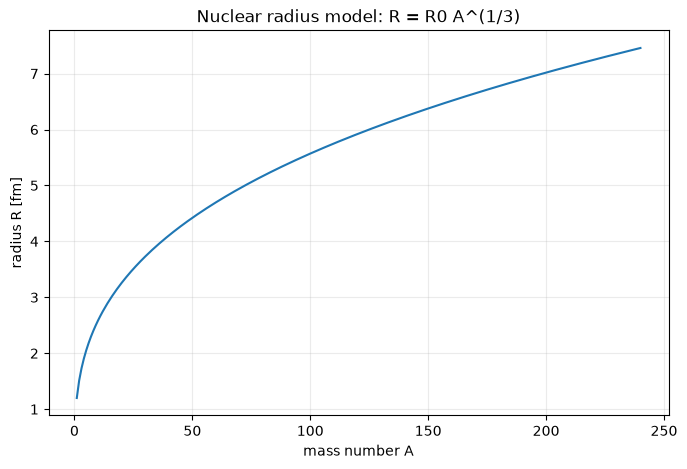

In [5]:
A_values = np.arange(1, 241)
R_values = np.array([nuclear_radius_fm(int(A)) for A in A_values])

plt.figure(figsize=(8, 5))
plt.plot(A_values, R_values)
plt.xlabel("mass number A")
plt.ylabel("radius R [fm]")
plt.title("Nuclear radius model: R = R0 A^(1/3)")
plt.grid(True, alpha=0.25)
plt.show()

## 3. Semi-empirical mass formula

A useful educational model for nuclear binding energy is the semi-empirical mass formula:

$$
B(A,Z)
=
a_v A
- a_s A^{2/3}
- a_c \frac{Z(Z-1)}{A^{1/3}}
- a_a \frac{(A-2Z)^2}{A}
+ \delta(A,Z)
$$

This is not exact, but it captures major trends:

- volume binding,
- surface correction,
- Coulomb repulsion,
- neutron-proton asymmetry,
- pairing effects.

In [6]:
# Coefficients in MeV.
# These are educational approximate values.
A_V = 15.75
A_S = 17.80
A_C = 0.711
A_A = 23.70
A_P = 11.18

def pairing_delta(A: int, Z: int) -> float:
    N = A - Z
    if A % 2 == 1:
        return 0.0
    if Z % 2 == 0 and N % 2 == 0:
        return +A_P / math.sqrt(A)
    return -A_P / math.sqrt(A)

def binding_energy_mev(A: int, Z: int) -> float:
    if A <= 0 or Z <= 0 or Z > A:
        return float("nan")

    volume = A_V * A
    surface = A_S * A**(2/3)
    coulomb = A_C * Z * (Z - 1) / A**(1/3)
    asymmetry = A_A * (A - 2*Z)**2 / A
    pairing = pairing_delta(A, Z)

    return volume - surface - coulomb - asymmetry + pairing

def binding_energy_per_nucleon(A: int, Z: int) -> float:
    return binding_energy_mev(A, Z) / A

for name, nucleus in examples.items():
    B = binding_energy_mev(nucleus.A, nucleus.Z)
    print(f"{name:>12}: B ≈ {B:8.2f} MeV, B/A ≈ {B/nucleus.A:5.2f} MeV/nucleon")

    helium-4: B ≈    22.84 MeV, B/A ≈  5.71 MeV/nucleon
   carbon-12: B ≈    89.61 MeV, B/A ≈  7.47 MeV/nucleon
     iron-56: B ≈   495.38 MeV, B/A ≈  8.85 MeV/nucleon
 uranium-238: B ≈  1814.73 MeV, B/A ≈  7.62 MeV/nucleon


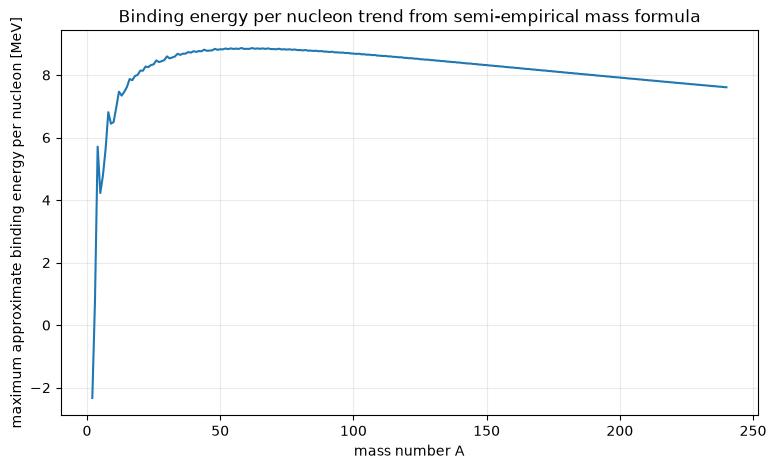

Approximate peak: A=58, Z=26, B/A=8.865 MeV


In [7]:
def best_Z_for_A(A: int) -> int:
    candidates = range(1, A + 1)
    return max(candidates, key=lambda Z: binding_energy_mev(A, Z))

A_values = np.arange(2, 241)
best_Z_values = np.array([best_Z_for_A(int(A)) for A in A_values])
best_B_per_A = np.array([
    binding_energy_per_nucleon(int(A), int(Z))
    for A, Z in zip(A_values, best_Z_values)
])

plt.figure(figsize=(9, 5))
plt.plot(A_values, best_B_per_A)
plt.xlabel("mass number A")
plt.ylabel("maximum approximate binding energy per nucleon [MeV]")
plt.title("Binding energy per nucleon trend from semi-empirical mass formula")
plt.grid(True, alpha=0.25)
plt.show()

peak_index = int(np.nanargmax(best_B_per_A))
print(
    "Approximate peak:",
    f"A={A_values[peak_index]},",
    f"Z={best_Z_values[peak_index]},",
    f"B/A={best_B_per_A[peak_index]:.3f} MeV"
)

## 4. Rough stability and decay tendencies

A simple educational simulator can classify a nucleus using heuristics.

This is not a replacement for a real chart of nuclides, but it helps users understand the direction of common decay modes.

Basic ideas:

- Too many neutrons tends to favor beta-minus decay.
- Too many protons tends to favor beta-plus decay or electron capture.
- Very heavy nuclei may alpha decay.
- Extremely heavy nuclei may fission.

In [8]:
def approximate_stable_N_for_Z(Z: int) -> float:
    # Educational curve:
    # Light nuclei: N ≈ Z
    # Heavy nuclei: N/Z rises gradually.
    return Z * (1.0 + 0.0065 * Z)

def suggest_decay_mode(nucleus: Nucleus) -> str:
    Z, N, A = nucleus.Z, nucleus.N, nucleus.A
    expected_N = approximate_stable_N_for_Z(Z)
    difference = N - expected_N

    if Z >= 84 and A >= 200:
        if difference > 10:
            return "alpha decay likely; beta-minus may also compete"
        return "alpha decay or spontaneous fission possible"

    if difference > max(2.0, 0.08 * A):
        return "neutron-rich: beta-minus decay tendency"

    if difference < -max(2.0, 0.08 * A):
        return "proton-rich: beta-plus decay or electron capture tendency"

    return "near simple stability band"

test_nuclei = {
    "carbon-12": Nucleus(6, 6),
    "carbon-14": Nucleus(6, 8),
    "oxygen-15": Nucleus(8, 7),
    "iron-56": Nucleus(26, 30),
    "uranium-238": Nucleus(92, 146),
}

for name, nucleus in test_nuclei.items():
    print(f"{name:>12}: {suggest_decay_mode(nucleus)}")

   carbon-12: near simple stability band
   carbon-14: near simple stability band
   oxygen-15: near simple stability band
     iron-56: near simple stability band
 uranium-238: alpha decay or spontaneous fission possible


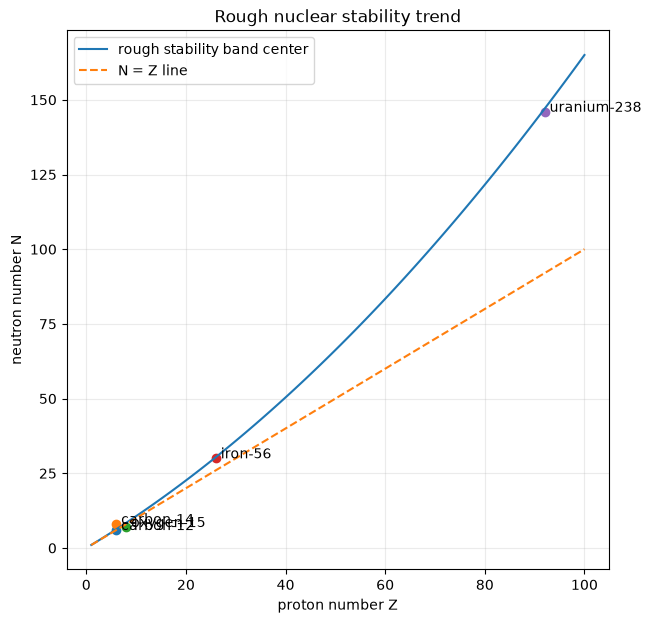

In [9]:
Z_values = np.arange(1, 101)
stable_N_values = np.array([approximate_stable_N_for_Z(int(Z)) for Z in Z_values])

plt.figure(figsize=(7, 7))
plt.plot(Z_values, stable_N_values, label="rough stability band center")
plt.plot(Z_values, Z_values, linestyle="--", label="N = Z line")

for name, nucleus in test_nuclei.items():
    plt.scatter(nucleus.Z, nucleus.N)
    plt.text(nucleus.Z + 1, nucleus.N, name)

plt.xlabel("proton number Z")
plt.ylabel("neutron number N")
plt.title("Rough nuclear stability trend")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 5. Toy pair potential

A visual particle simulation can use a qualitative pair potential:

$$
V_{\text{nuclear}}(r)
=
A e^{-r/r_1}
-
B e^{-r/r_2}
$$

The first term creates short-range repulsion.

The second term creates medium-short-range attraction.

For proton-proton interactions, add Coulomb repulsion:

$$
V_{\text{coulomb}}(r) = k\frac{e^2}{r}
$$

This does not represent a complete physical nuclear force. It is a useful visual rule for a conceptual simulator.

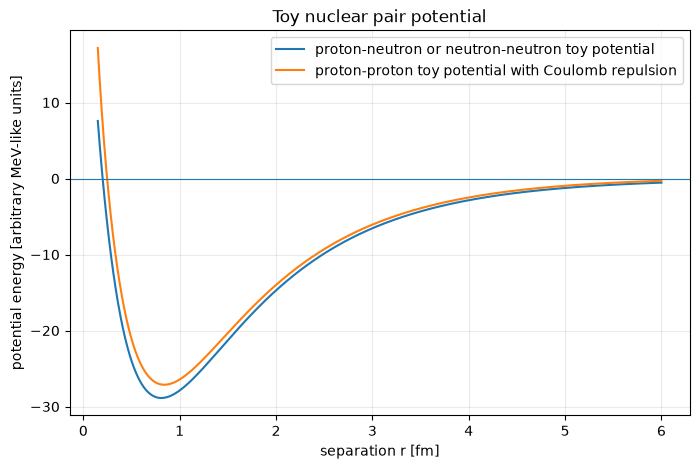

In [10]:
def nuclear_pair_potential(r, A_rep=120.0, B_attr=80.0, r1=0.35, r2=1.2):
    return A_rep * np.exp(-r / r1) - B_attr * np.exp(-r / r2)

def coulomb_potential_pp(r, strength=1.44):
    # In nuclear units, e^2/(4pi epsilon0) ≈ 1.44 MeV fm.
    return strength / r

r = np.linspace(0.15, 6.0, 1000)
V_pn = nuclear_pair_potential(r)
V_pp = nuclear_pair_potential(r) + coulomb_potential_pp(r)

plt.figure(figsize=(8, 5))
plt.plot(r, V_pn, label="proton-neutron or neutron-neutron toy potential")
plt.plot(r, V_pp, label="proton-proton toy potential with Coulomb repulsion")
plt.axhline(0, linewidth=0.8)
plt.xlabel("separation r [fm]")
plt.ylabel("potential energy [arbitrary MeV-like units]")
plt.title("Toy nuclear pair potential")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 6. How this maps to C++

A C++ nucleus module can begin with simple data and utility functions.

```cpp
struct Nucleus {
    int Z; // protons
    int N; // neutrons

    int A() const {
        return Z + N;
    }

    double neutronToProtonRatio() const {
        return Z == 0 ? 0.0 : static_cast<double>(N) / Z;
    }
};

double nuclearRadiusFm(int A) {
    constexpr double R0 = 1.2;
    return R0 * std::cbrt(static_cast<double>(A));
}

double bindingEnergyMeV(int A, int Z) {
    // Implement semi-empirical mass formula here.
    // Return approximate binding energy in MeV.
}

enum class DecaySuggestion {
    StableLike,
    BetaMinus,
    BetaPlusOrElectronCapture,
    Alpha,
    FissionCandidate
};
```

Good UI controls for the browser version:

- proton number slider,
- neutron number slider,
- isotope label,
- nuclear radius display,
- binding energy per nucleon,
- rough decay suggestion,
- force visualization between nucleons,
- stable-band chart.